In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"D:\DS115-VIS\.venv\Project1_Predictive-Maintenance\ai4i_fused.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,PWF,OSF,RNF,date,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,avg_wind_speed_kmh,avg_sea_level_pres_hpa
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4


In [2]:
# Clean trailing and leading spaces from column names
df.columns = df.columns.str.strip()
df.columns = (df.columns.str.strip().str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace('<', '', regex=False))
print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'date', 'avg_temp_c', 'min_temp_c', 'max_temp_c', 'precipitation_mm', 'avg_wind_speed_kmh', 'avg_sea_level_pres_hpa']


In [3]:
# 2. Sort data for time-series compatibility
# Chronological order is mandatory for accurate rolling calculations
df = df.sort_values(by=['date', 'UDI']).reset_index(drop=True)

In [4]:
# 3. Select Target Telemetry Features
# These are the main continuous sensor and weather columns from image
sensor_features = [
    'Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min',
    'avg_temp_c', 'min_temp_c', 'max_temp_c', 'precipitation_mm', 'aavg_wind_speed_kmh', 'avg_sea_level_pres_hpa'
]

In [5]:
# Define the rolling window size (Operational window size - e.g., 5 logs)
window_size = 5
df.head(5)

,UDI,Product ID,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,...,PWF,OSF,RNF,date,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,avg_wind_speed_kmh,avg_sea_level_pres_hpa
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4


In [6]:
print("Starting feature engineering...")


Starting feature engineering...


In [7]:
# 4. Engineer Rolling Mean, Standard Deviation, and Variance
# Perform calculations inside a new DataFrame
engineered_features = pd.DataFrame(index=df.index)


In [8]:
for col in sensor_features:
    # Check if the column exists in the dataset
    if col in df.columns:
        # Rolling Mean
        engineered_features[f'{col}_roll_mean'] = df[col].rolling(window=window_size).mean()
        
        # Rolling Standard Deviation
        engineered_features[f'{col}_roll_std'] = df[col].rolling(window=window_size).std()
        
        # Rolling Variance
        engineered_features[f'{col}_roll_var'] = df[col].rolling(window=window_size).var()

In [9]:
# 5. Combine with original metadata and targets
# Includes UDI, Product ID, Machine failure, and specific failure modes
meta_cols = ['UDI', 'Product ID', 'Type', 'date', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
# Filter out names to match what is present in the dataset
meta_cols = [c for c in meta_cols if c in df.columns]

final_df = pd.concat([df[meta_cols], engineered_features], axis=1)


In [10]:
# 6. Drop NaN rows generated by the rolling window warmup buffer
final_df.dropna(inplace=True)
df.head(5)


,UDI,Product ID,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,...,PWF,OSF,RNF,date,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,avg_wind_speed_kmh,avg_sea_level_pres_hpa
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,0,0,2020-01-01,25.7,22.5,30.3,27.9,6.4,1014.4


In [11]:
# 7. Verify the output structure and save the file
print(f"Processed dataset shape: {final_df.shape}")
print(final_df.head())

# Save the final engineered dataset
final_df.to_csv("engineered_iot_weather_dataset.csv", index=False)
print("File successfully saved as 'engineered_iot_weather_dataset.csv'!")


Processed dataset shape: (9996, 40)
   UDI Product ID Type        date  Machine failure  TWF  HDF  PWF  OSF  RNF  \
4    5     L47184    L  2020-01-01                0    0    0    0    0    0   
5    6     M14865    M  2020-01-01                0    0    0    0    0    0   
6    7     L47186    L  2020-01-01                0    0    0    0    0    0   
7    8     L47187    L  2020-01-01                0    0    0    0    0    0   
8    9     M14868    M  2020-01-01                0    0    0    0    0    0   

   ...  min_temp_c_roll_var  max_temp_c_roll_mean  max_temp_c_roll_std  \
4  ...                  0.0                  30.3                  0.0   
5  ...                  0.0                  30.3                  0.0   
6  ...                  0.0                  30.3                  0.0   
7  ...                  0.0                  30.3                  0.0   
8  ...                  0.0                  30.3                  0.0   

   max_temp_c_roll_var  precipitation_

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [13]:
# 1. Define original sensor features & target variable
# Using only the original features as requested for the baseline
base_features = ['Air temperature K', 'Process temperature K', 'Rotational speed rpm', 'Torque Nm', 'Tool wear min']
target = 'Machine failure'  
# Assuming 'Machine failure' stands for Machine Failure 
# Filter features that exist in df to avoid any KeyErrors
base_features = [col for col in base_features if col in df.columns]

In [14]:
# 2. Prepare the dataset
# Drop any rows where features or target might have missing values
baseline_df = df[base_features + [target]].dropna()

X = baseline_df[base_features]
y = baseline_df[target]

In [15]:
# 3. Train-Test Split (Stratified to handle class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
from imblearn.over_sampling import SMOTE

In [17]:
# 1. Apply SMOTE and Train
print("Applying SMOTE + Probability Tuning...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

baseline_rf = RandomForestClassifier(random_state=42, n_estimators=100)
baseline_rf.fit(X_train_resampled, y_train_resampled)

# 2. Use predict_proba instead of predict
y_probs = baseline_rf.predict_proba(X_test)[:, 1]

# 3. Tweak this value (Try 0.6 or 0.7 to raise precision)
custom_threshold = 0.65  
y_pred = (y_probs >= custom_threshold).astype(int)

# Evaluate and print scores
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='binary')

print("\n================ NEW TUNED MODEL METRICS ================")
print(f"Accuracy Score : {accuracy:.4f}")
print(f"F1-Score       : {f1:.4f}")
print("========================================================")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Applying SMOTE + Probability Tuning...

================ NEW TUNED MODEL METRICS ================
Accuracy Score : 0.9695
F1-Score       : 0.6211

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98      1932
           1       0.54      0.74      0.62        68

    accuracy                           0.97      2000
   macro avg       0.76      0.86      0.80      2000
weighted avg       0.98      0.97      0.97      2000



In [18]:
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score

In [19]:
# 1. Import Advanced Boosting Algorithms
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    'XGBoost': XGBClassifier(),
    'LightGBM': LGBMClassifier(),
    'CatBoost': CatBoostClassifier()
}

print("Initializing Advanced Model Exploration Framework...")

# 2. Define the Pipelines (SMOTE + Model)
# This will perform automated SMOTE training while preventing data leakage during tuning.
boosting_pipelines = {
    'XGBoost': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0))
    ]),
    'LightGBM': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', LGBMClassifier(random_state=42, verbose=-1))
    ]),
    'CatBoost': ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', CatBoostClassifier(random_state=42, verbose=0))
    ])
}

Initializing Advanced Model Exploration Framework...


In [20]:
# 3. Define Hyperparameter Tuning Grids
# Hyperparameters have been limited to ensure GridSearchCV runs quickly.
boosting_param_grids = {
    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.05, 0.1]
    },

    'LightGBM': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5],
        'model__learning_rate': [0.05, 0.1]
    },

    'CatBoost': {
        'model__iterations': [100, 200],
        'model__depth': [4, 6],
        'model__learning_rate': [0.05, 0.1]
    }
}


In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report

best_models = {}

for name in boosting_pipelines:

    print(f"\nRunning GridSearchCV for {name}")

    grid = GridSearchCV(
        estimator=boosting_pipelines[name],
        param_grid=boosting_param_grids[name],
        scoring='f1',
        cv=3,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_

    print("Best Parameters:", grid.best_params_)

# 4. Evaluate All Tuned Advanced Models on Test Data
print("\n================ ADVANCED MODELS EVALUATION ================")
for name, model in best_models.items():
      print(f"\n{name}")
      y_pred = model.predict(X_test)
      print("F1 Score: ", f1_score(y_test, y_pred))

      print(classification_report(y_test, y_pred))






Running GridSearchCV for XGBoost
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

Running GridSearchCV for LightGBM
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}

Running GridSearchCV for CatBoost
Best Parameters: {'model__depth': 6, 'model__iterations': 200, 'model__learning_rate': 0.1}

================ ADVANCED MODELS EVALUATION ================

XGBoost
F1 Score:  0.6096256684491979
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.48      0.84      0.61        68

    accuracy                           0.96      2000
   macro avg       0.74      0.90      0.80      2000
weighted avg       0.98      0.96      0.97      2000


LightGBM
F1 Score:  0.6136363636363636
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.50      0.

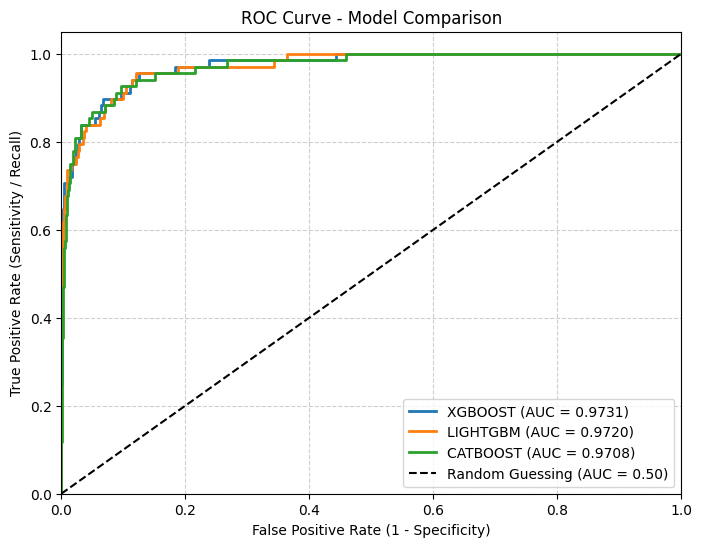

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

for name, model in best_models.items():
    # Model probabilities (Class 1 probabilities only)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # Decision function for models without predict_proba
        y_prob = model.decision_function(X_test)
        
    # Compute False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    # Plot the ROC curve for each model
    plt.plot(fpr, tpr, label=f'{name.upper()} (AUC = {auc_score:.4f})', linewidth=2)

# Reference diagonal line (Random guessing line)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve - Model Comparison')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, roc_curve

def run_hyperparameter_tuning(pipeline, X_train, y_train):
    """
    Runs hyperparameter optimization on the composite pipeline.
    Expects a pipeline that contains both the balancer and the estimator.
    """
    # Define a clean search space specifically optimized for LightGBM
    param_distributions = {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__num_leaves': [31, 50, 70],
        'model__max_depth': [-1, 5, 10],
        'model__subsample': [0.8, 1.0]
    }
    
    # Using RandomizedSearchCV to keep memory and execution footprint optimal
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=10,
        scoring='f1_macro', # F1 Macro is ideal for <2% imbalanced data
        cv=5,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    print(f"🔥 Best Parameters Found: {search.best_params_}")
    return search.best_estimator_

def generate_evaluation_plots(y_true, y_pred_proba, y_pred):
    """
    Generates strict evaluation charts required for imbalanced validation documentation.
    """
    # 1. Calculate Precision-Recall Curve (Most critical for <2% imbalance)
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)
    
    # 2. Calculate ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plotting both side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    # PR Curve Plot
    ax[0].plot(recall, precision, label=f'PR-AUC = {pr_auc:.4f}', color='darkorange', lw=2)
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].set_title('Precision-Recall Curve')
    ax[0].legend(loc="lower left")
    ax[0].grid(True)
    
    # ROC Curve Plot
    ax[1].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}', color='blue', lw=2)
    ax[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title('ROC Curve')
    ax[1].legend(loc="lower right")
    ax[1].grid(True)
    
    plt.tight_layout()
    plt.savefig('evaluation_curves.png') # Keeps a physical track for the documentation
    plt.show()
    
    # Output textual evaluation reports
    print("\n📊 Classification Report:\n", classification_report(y_true, y_pred))
    print("\n🧩 Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

In [24]:
param_grids = {

    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.8, 1.0]
    },

    'LightGBM': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__num_leaves': [31, 50, 70],
        'model__max_depth': [-1, 5, 10],
        'model__subsample': [0.8, 1.0]
    },

    'CatBoost': {
        'model__iterations': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__depth': [4, 6, 8]
    }

}

In [25]:
def run_hyperparameter_tuning(pipeline, params, X_train, y_train):

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=10,
        cv=5,
        scoring='f1',
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    print("\nBest Parameters:")
    print(search.best_params_)

    print("Best CV Score:", search.best_score_)

    return search.best_estimator_

In [26]:
best_models = {}

for name, pipe in boosting_pipelines.items():

    print("\n" + "="*60)
    print(f"Tuning {name}")
    print("="*60)

    best_model = run_hyperparameter_tuning(
        pipe,
        param_grids[name],
        X_train,
        y_train
    )

    best_models[name] = best_model


Tuning XGBoost

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.1}
Best CV Score: 0.6507279093538636

Tuning LightGBM

Best Parameters:
{'model__subsample': 0.8, 'model__num_leaves': 50, 'model__n_estimators': 300, 'model__max_depth': 10, 'model__learning_rate': 0.1}
Best CV Score: 0.6711515141158757

Tuning CatBoost

Best Parameters:
{'model__learning_rate': 0.1, 'model__iterations': 300, 'model__depth': 6}
Best CV Score: 0.5641277417981843



XGBoost
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.56      0.78      0.65        68

    accuracy                           0.97      2000
   macro avg       0.78      0.88      0.82      2000
weighted avg       0.98      0.97      0.97      2000



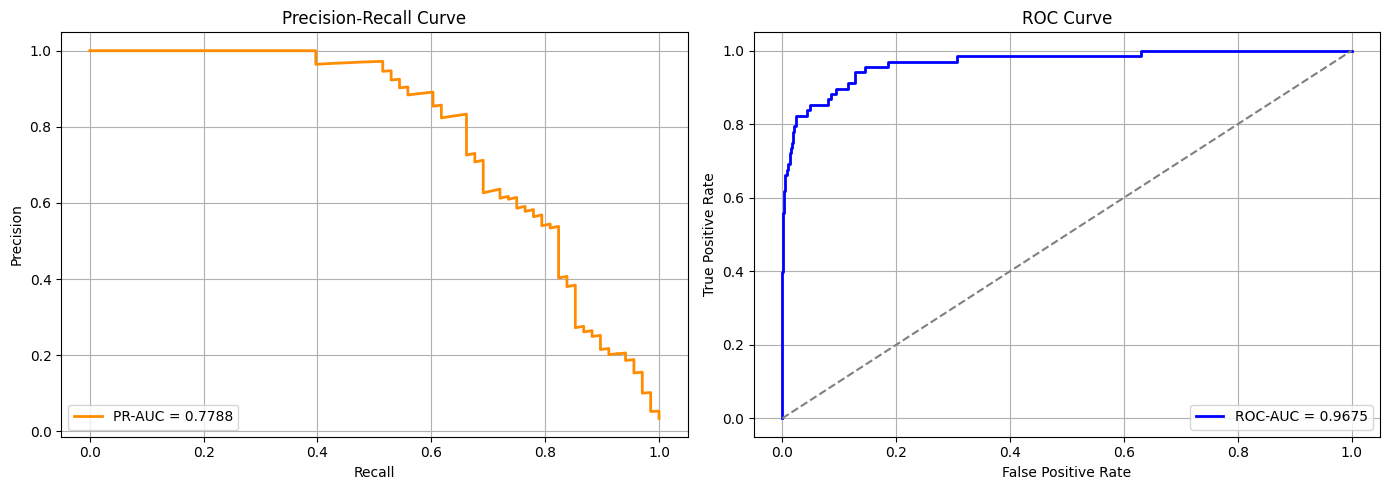


📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      1932
           1       0.56      0.78      0.65        68

    accuracy                           0.97      2000
   macro avg       0.78      0.88      0.82      2000
weighted avg       0.98      0.97      0.97      2000


🧩 Confusion Matrix:
 [[1891   41]
 [  15   53]]

LightGBM
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.66      0.76      0.71        68

    accuracy                           0.98      2000
   macro avg       0.82      0.88      0.85      2000
weighted avg       0.98      0.98      0.98      2000



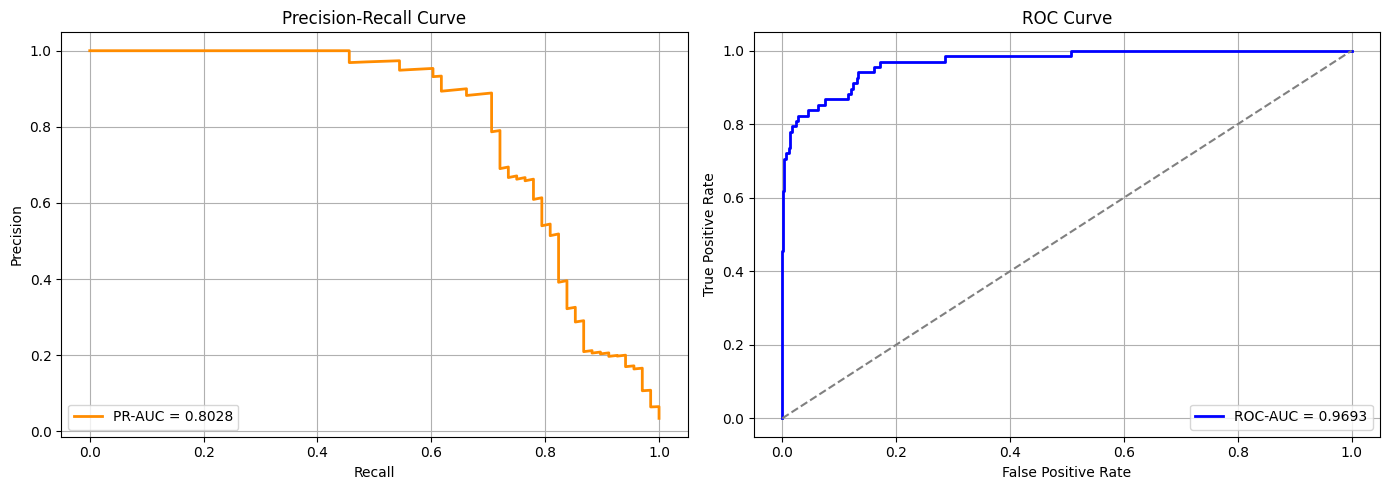


📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.66      0.76      0.71        68

    accuracy                           0.98      2000
   macro avg       0.82      0.88      0.85      2000
weighted avg       0.98      0.98      0.98      2000


🧩 Confusion Matrix:
 [[1905   27]
 [  16   52]]

CatBoost
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.49      0.82      0.62        68

    accuracy                           0.96      2000
   macro avg       0.74      0.90      0.80      2000
weighted avg       0.98      0.96      0.97      2000



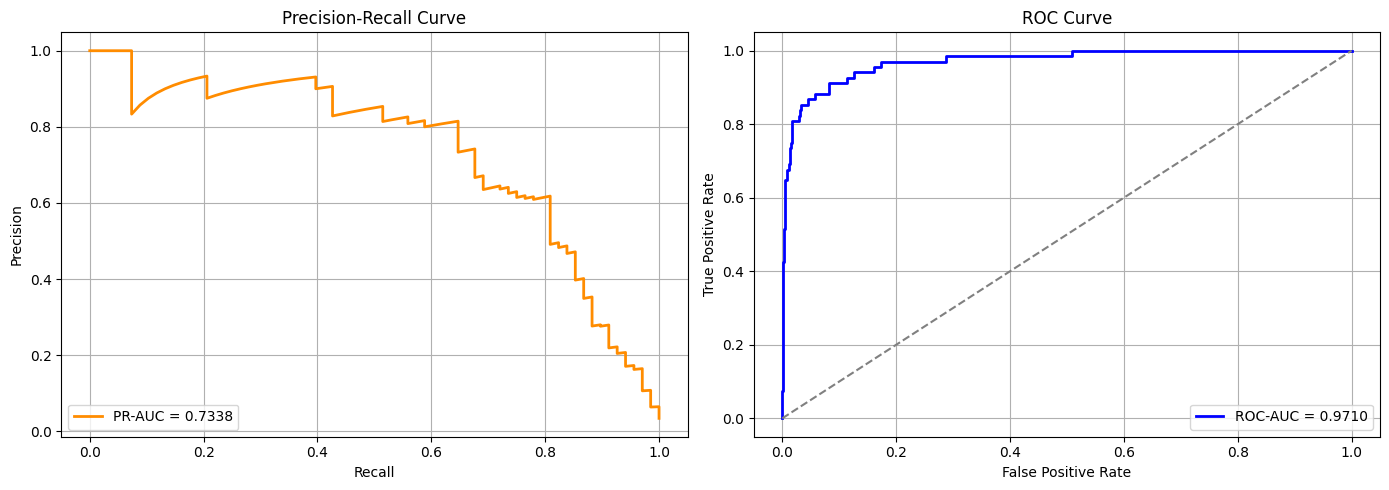


📊 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98      1932
           1       0.49      0.82      0.62        68

    accuracy                           0.96      2000
   macro avg       0.74      0.90      0.80      2000
weighted avg       0.98      0.96      0.97      2000


🧩 Confusion Matrix:
 [[1874   58]
 [  12   56]]


In [27]:
for name, model in best_models.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(classification_report(y_test, y_pred))

    generate_evaluation_plots(
        y_test,
        y_prob,
        y_pred
    )

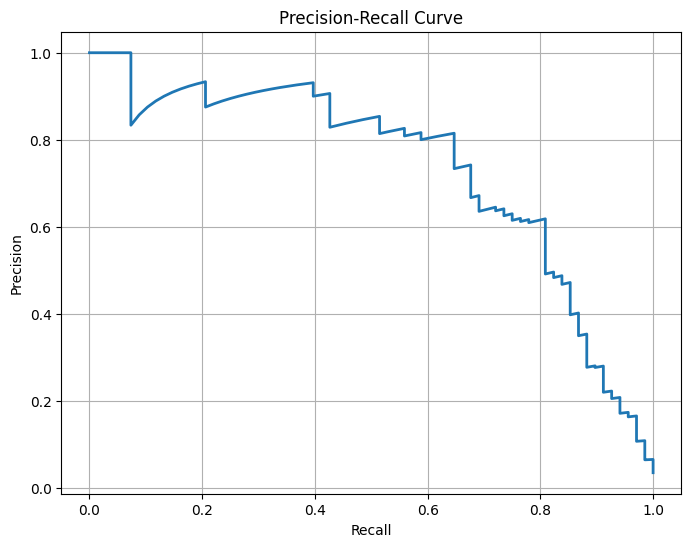

In [28]:
# Get prediction probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Plot Precision-Recall Curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()